In [13]:
import tensorflow.keras as tf

from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import load_img
import matplotlib.pyplot as plt
import numpy as np
import os
print("Importe erledigt")

Importe erledigt


In [14]:
basedir = r'biene_hummel'
dir_dict = {
    'DataSet' : os.path.join(basedir,'DataSet'),
    'toDetect' : os.path.join(basedir,'toDetect'),
    'download': os.path.join(basedir,'download'),
    'train':  os.path.join(basedir,'train'),
    'test':  os.path.join(basedir,'test'),
    'valid': os.path.join(basedir,'valid'),
    'train_bee': os.path.join(basedir,'train','biene'),
    'train_bumble': os.path.join(basedir,'train','hummel'),
    'test_bee': os.path.join(basedir,'test','biene'),
    'test_bumble': os.path.join(basedir,'test','hummel'),
    'valid_bee': os.path.join(basedir,'valid','biene'),
    'valid_bumble': os.path.join(basedir,'valid','hummel')}

# Erzeuge die Verzeichnisse (nur wenn sie noch nicht vorhanden sind)
for key in dir_dict:
    if not os.path.exists(dir_dict[key]): 
        os.makedirs(dir_dict[key])

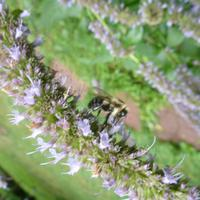

In [15]:
from IPython.display import Image
Image(os.path.join(dir_dict['download'],'8.jpg'))

In [16]:
model = InceptionV3(weights='imagenet')
model.summary()

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 299, 299, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_94 (Conv2D)             (None, 149, 149, 32  864         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_94 (BatchN  (None, 149, 149, 32  96         ['conv2d_94[0][0]']              
 ormalization)                  )                                                      

 batch_normalization_99 (BatchN  (None, 35, 35, 64)  192         ['conv2d_99[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_101 (Batch  (None, 35, 35, 64)  192         ['conv2d_101[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 batch_normalization_104 (Batch  (None, 35, 35, 96)  288         ['conv2d_104[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 batch_normalization_105 (Batch  (None, 35, 35, 32)  96          ['conv2d_105[0][0]']             
 Normaliza

                                                                                                  
 batch_normalization_116 (Batch  (None, 35, 35, 64)  192         ['conv2d_116[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_116 (Activation)    (None, 35, 35, 64)   0           ['batch_normalization_116[0][0]']
                                                                                                  
 conv2d_114 (Conv2D)            (None, 35, 35, 48)   13824       ['mixed1[0][0]']                 
                                                                                                  
 conv2d_117 (Conv2D)            (None, 35, 35, 96)   55296       ['activation_116[0][0]']         
                                                                                                  
 batch_nor

                                                                                                  
 max_pooling2d_6 (MaxPooling2D)  (None, 17, 17, 288)  0          ['mixed2[0][0]']                 
                                                                                                  
 mixed3 (Concatenate)           (None, 17, 17, 768)  0           ['activation_120[0][0]',         
                                                                  'activation_123[0][0]',         
                                                                  'max_pooling2d_6[0][0]']        
                                                                                                  
 conv2d_128 (Conv2D)            (None, 17, 17, 128)  98304       ['mixed3[0][0]']                 
                                                                                                  
 batch_normalization_128 (Batch  (None, 17, 17, 128)  384        ['conv2d_128[0][0]']             
 Normaliza

                                                                  'activation_133[0][0]']         
                                                                                                  
 conv2d_138 (Conv2D)            (None, 17, 17, 160)  122880      ['mixed4[0][0]']                 
                                                                                                  
 batch_normalization_138 (Batch  (None, 17, 17, 160)  480        ['conv2d_138[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_138 (Activation)    (None, 17, 17, 160)  0           ['batch_normalization_138[0][0]']
                                                                                                  
 conv2d_139 (Conv2D)            (None, 17, 17, 160)  179200      ['activation_138[0][0]']         
          

 Normalization)                                                                                   
                                                                                                  
 activation_148 (Activation)    (None, 17, 17, 160)  0           ['batch_normalization_148[0][0]']
                                                                                                  
 conv2d_149 (Conv2D)            (None, 17, 17, 160)  179200      ['activation_148[0][0]']         
                                                                                                  
 batch_normalization_149 (Batch  (None, 17, 17, 160)  480        ['conv2d_149[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_149 (Activation)    (None, 17, 17, 160)  0           ['batch_normalization_149[0][0]']
          

                                                                                                  
 batch_normalization_159 (Batch  (None, 17, 17, 192)  576        ['conv2d_159[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_159 (Activation)    (None, 17, 17, 192)  0           ['batch_normalization_159[0][0]']
                                                                                                  
 conv2d_155 (Conv2D)            (None, 17, 17, 192)  147456      ['mixed6[0][0]']                 
                                                                                                  
 conv2d_160 (Conv2D)            (None, 17, 17, 192)  258048      ['activation_159[0][0]']         
                                                                                                  
 batch_nor

                                                                                                  
 conv2d_164 (Conv2D)            (None, 17, 17, 192)  147456      ['mixed7[0][0]']                 
                                                                                                  
 conv2d_168 (Conv2D)            (None, 17, 17, 192)  258048      ['activation_167[0][0]']         
                                                                                                  
 batch_normalization_164 (Batch  (None, 17, 17, 192)  576        ['conv2d_164[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 batch_normalization_168 (Batch  (None, 17, 17, 192)  576        ['conv2d_168[0][0]']             
 Normalization)                                                                                   
          

 batch_normalization_170 (Batch  (None, 8, 8, 320)   960         ['conv2d_170[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_172 (Activation)    (None, 8, 8, 384)    0           ['batch_normalization_172[0][0]']
                                                                                                  
 activation_173 (Activation)    (None, 8, 8, 384)    0           ['batch_normalization_173[0][0]']
                                                                                                  
 activation_176 (Activation)    (None, 8, 8, 384)    0           ['batch_normalization_176[0][0]']
                                                                                                  
 activation_177 (Activation)    (None, 8, 8, 384)    0           ['batch_normalization_177[0][0]']
          

                                                                                                  
 activation_185 (Activation)    (None, 8, 8, 384)    0           ['batch_normalization_185[0][0]']
                                                                                                  
 activation_186 (Activation)    (None, 8, 8, 384)    0           ['batch_normalization_186[0][0]']
                                                                                                  
 batch_normalization_187 (Batch  (None, 8, 8, 192)   576         ['conv2d_187[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_179 (Activation)    (None, 8, 8, 320)    0           ['batch_normalization_179[0][0]']
                                                                                                  
 mixed9_1 

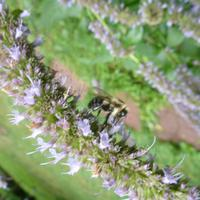

In [33]:
Image1 = os.path.join(dir_dict['download'],'8.jpg')
Image(Image1)

In [ ]:
import cv2
import os

Image1 = os.path.join(dir_dict['download'],'12.jpg')
Image2 = os.path.join(dir_dict['download'],'10.jpg')
Image3 = os.path.join(dir_dict['download'],'12.jpg')



img = cv2.imread(Image1)

    
x = image.img_to_array(img)
x = cv2.resize(img, dsize=(299, 299))
    
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
    #print(x.shape)
    #print(x)
    
prediction = model.predict(x)

decoded = decode_predictions(prediction, top=3)[0]
#print(decoded)

    
img = cv2.imread(Image1)
x = image.img_to_array(img)
x = cv2.resize(img, dsize=(598, 598))

txt_position_x,txt_position_y = 1,20
pos_x, pos_y = 1,20
for i in decoded:
    cv2.putText(
                x, #numpy array on which text is written
                'Klasse :{} - {:.2f}%'.format(lab,prob*100), #text
                (txt_position_x,txt_position_y), #position at which writing has to start
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (209, 80, 0, 255),
                3)
    
    
window_name = "Output"

cv2.imshow(window_name,x)
cv2.waitKey(0)
cv2.destroyAllWindows()


1/1 [==============================] - 0s 102ms/step
